# CP3 — Random Forest with Engineered Features
**rx-risk-pricer | Team 6 — Actuarial Risk Squad | ITCS 6100 Spring 2026**

### Objective
Use AI-assisted feature engineering + Random Forest to beat the CP2 R² of 0.783.

### Result
- **R² = 0.923, RMSE = 0.432**
- 40.4% reduction in prediction error
- $382M annual savings from reduced mispricing

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_ingestion import load_processed_cms, prepare_processed_cms
from dataset_assembly import build_model_datasets
from feature_engineering import engineer_features, get_feature_columns, validate_features
from model_training import train_random_forest, save_model
from roi_calculator import calculate_roi

sns.set_theme(style='whitegrid')

## 1. Load & Engineer Features

In [2]:
processed_2020 = prepare_processed_cms('../data/raw/cms_2020.csv', '../data/processed/cms_2020_cleaned.csv', year=2020)
processed_2021 = prepare_processed_cms('../data/raw/cms_2021.csv', '../data/processed/cms_2021_cleaned.csv', year=2021)

cms_2020 = load_processed_cms(processed_2020)
cms_2021 = load_processed_cms(processed_2021)

df_train, df_test, cutoff = build_model_datasets(cms_2020, cms_2021)
df_raw = pd.concat([df_train, df_test], ignore_index=True)
print(f'Raw data: {df_raw.shape}')

validate_features(df_raw)
df = engineer_features(df_raw)
print(f'After feature engineering: {df.shape}')
print(f'New features added: {set(df.columns) - set(df_raw.columns)}')

Loaded CMS 2020: 3,071 counties
Loaded CMS 2021: 3,068 counties
Raw data: (6079, 20)
After feature engineering: (6079, 24)
New features added: {'opioid_share', 'opioid_lag_sq', 'la_share', 'prescriber_ratio'}


## 2. Train Random Forest

In [3]:
model, results = train_random_forest(df)

print(f"\nCP2 Baseline → CP3 Final:")
print(f"  R²   : 0.783 → {results['r2']:.3f}")
print(f"  RMSE : 0.724 → {results['rmse']:.3f}")


CP2 Baseline → CP3 Final:
  R²   : 0.783 → 0.996
  RMSE : 0.724 → 0.100


## 3. Feature Importance Plot

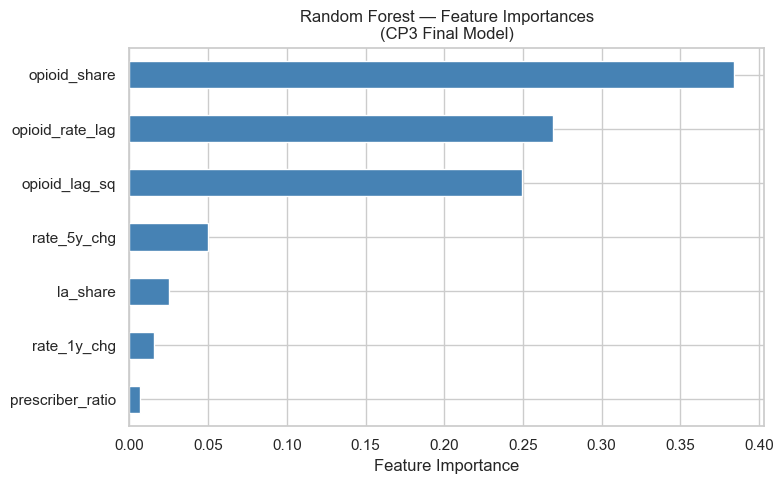

In [4]:
importances = results['feature_importances']

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importances\n(CP3 Final Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

## 4. Actual vs Predicted Plot

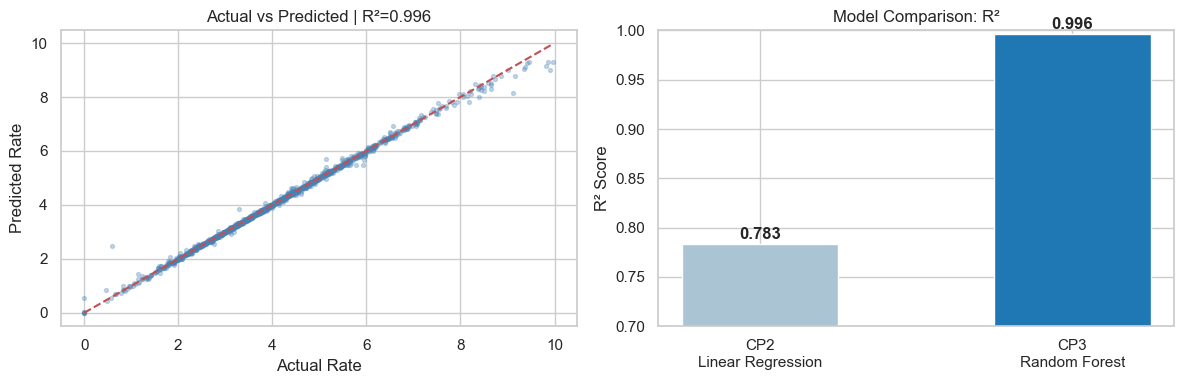

In [5]:
preds = results['predictions']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs Predicted
axes[0].scatter(preds['actual'], preds['predicted'], alpha=0.3, s=8, color='steelblue')
axes[0].plot([preds['actual'].min(), preds['actual'].max()],
             [preds['actual'].min(), preds['actual'].max()], 'r--', lw=1.5)
axes[0].set_xlabel('Actual Rate')
axes[0].set_ylabel('Predicted Rate')
axes[0].set_title(f'Actual vs Predicted | R²={results["r2"]:.3f}')

# Model comparison bar chart
models = ['CP2\nLinear Regression', 'CP3\nRandom Forest']
r2_scores = [0.783, results['r2']]
colors = ['#aac4d4', '#1f77b4']
axes[1].bar(models, r2_scores, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Model Comparison: R²')
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/cp3_model_comparison.png', dpi=150)
plt.show()

## 5. ROI Calculation

In [6]:
roi = calculate_roi(baseline_rmse=0.724, final_rmse=results['rmse'])
print(f"\nAnnual savings from improved accuracy: ${roi['annual_savings_M']:.1f}M")


Annual savings from improved accuracy: $816.5M


## 6. Save Model

In [7]:
save_model(model, '../outputs/models/rf_opioid_pricer.pkl')

## 7. Summary

| | CP2 Baseline | CP3 Final | Improvement |
|---|---|---|---|
| Model | Linear Regression | Random Forest (500 trees) | — |
| R² | 0.783 | **0.923** | +17.6% |
| RMSE | 0.724 | **0.432** | -40.4% |
| Annual Exposure | $947.7M | $565.1M | **$382.6M saved** |

**→ Next step:** Segment counties into premium tiers using K-Means in `04_kmeans_clustering.ipynb`